In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving 6g_fl_telemetry_200_clients.csv to 6g_fl_telemetry_200_clients.csv


In [4]:
df = pd.read_csv("6g_fl_telemetry_200_clients.csv")
df.head()

,client_id,regime,window_idx,timestamp_s,delta_s,PRBmean,PRBp95,CQImean,CQIp05,SINR_dB,...,slice_imbalance,slice_entropy,p_eMBB,p_URLLC,p_mMTC,p_XR,p_BE,reward,sla_ok_current,sla_ok_next
0,C001,heavy,0,0,90,80.803512,86.500911,9.050417,7.037909,14.749196,...,0.143235,1.989346,0.250143,0.220381,0.300872,0.228580,2.390094e-05,0.956820,0,0
1,C001,heavy,1,90,90,77.990717,82.283198,10.632818,8.189750,16.967466,...,0.360051,1.485916,0.625021,0.210906,0.054496,0.108263,1.315028e-03,0.999341,0,0
2,C001,heavy,2,180,90,76.997972,85.430804,9.707914,9.369617,15.160290,...,0.217892,1.815998,0.374542,0.087727,0.170873,0.365728,1.130690e-03,0.998121,0,0
3,C001,heavy,3,270,90,78.286703,88.711145,10.763436,7.928468,25.263540,...,0.283645,1.663326,0.267286,0.021608,0.254088,0.455279,1.738984e-03,0.942493,0,1
4,C001,heavy,4,360,90,83.066097,89.254906,10.651110,8.640565,12.604191,...,0.263275,1.710624,0.508414,0.069643,0.219188,0.202755,2.889708e-08,1.000000,1,0


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (30000, 29)

Columns:
['client_id', 'regime', 'window_idx', 'timestamp_s', 'delta_s', 'PRBmean', 'PRBp95', 'CQImean', 'CQIp05', 'SINR_dB', 'BLER_DL', 'BLER_UL', 'HARQ_retx', 'UE', 'HO', 'DLthrmean_Mbps', 'ULthrmean_Mbps', 'lat_p50_ms', 'lat_p95_ms', 'slice_imbalance', 'slice_entropy', 'p_eMBB', 'p_URLLC', 'p_mMTC', 'p_XR', 'p_BE', 'reward', 'sla_ok_current', 'sla_ok_next']

Missing values:
client_id          0
regime             0
window_idx         0
timestamp_s        0
delta_s            0
PRBmean            0
PRBp95             0
CQImean            0
CQIp05             0
SINR_dB            0
BLER_DL            0
BLER_UL            0
HARQ_retx          0
UE                 0
HO                 0
DLthrmean_Mbps     0
ULthrmean_Mbps     0
lat_p50_ms         0
lat_p95_ms         0
slice_imbalance    0
slice_entropy      0
p_eMBB             0
p_URLLC            0
p_mMTC             0
p_XR               0
p_BE               0
reward             0
sla_ok_current     0
sla_ok_next 

In [6]:
print("sla_ok_current distribution:")
print(df["sla_ok_current"].value_counts())
print(df["sla_ok_current"].value_counts(normalize=True) * 100)

print("\nsla_ok_next distribution:")
print(df["sla_ok_next"].value_counts())
print(df["sla_ok_next"].value_counts(normalize=True) * 100)

sla_ok_current distribution:
sla_ok_current
1    17044
0    12956
Name: count, dtype: int64
sla_ok_current
1    56.813333
0    43.186667
Name: proportion, dtype: float64

sla_ok_next distribution:
sla_ok_next
1    17060
0    12940
Name: count, dtype: int64
sla_ok_next
1    56.866667
0    43.133333
Name: proportion, dtype: float64


In [7]:
df["network_issue_next"] = (df["sla_ok_next"] == 0).astype(int)

print(df["network_issue_next"].value_counts())
print(df["network_issue_next"].value_counts(normalize=True) * 100)

network_issue_next
0    17060
1    12940
Name: count, dtype: int64
network_issue_next
0    56.866667
1    43.133333
Name: proportion, dtype: float64


In [8]:
df_model = df.copy()

# حذف الأعمدة غير المناسبة
df_model = df_model.drop(columns=["sla_ok_next", "sla_ok_current", "client_id"])

# تحويل regime إلى one-hot encoding
df_model = pd.get_dummies(df_model, columns=["regime"], drop_first=True)

print(df_model.shape)
df_model.head()

(30000, 29)


,window_idx,timestamp_s,delta_s,PRBmean,PRBp95,CQImean,CQIp05,SINR_dB,BLER_DL,BLER_UL,...,p_eMBB,p_URLLC,p_mMTC,p_XR,p_BE,reward,network_issue_next,regime_impaired,regime_light,regime_medium
0,0,0,90,80.803512,86.500911,9.050417,7.037909,14.749196,0.033163,0.039564,...,0.250143,0.220381,0.300872,0.228580,2.390094e-05,0.956820,1,False,False,False
1,1,90,90,77.990717,82.283198,10.632818,8.189750,16.967466,0.002963,0.019622,...,0.625021,0.210906,0.054496,0.108263,1.315028e-03,0.999341,1,False,False,False
2,2,180,90,76.997972,85.430804,9.707914,9.369617,15.160290,0.034781,0.030924,...,0.374542,0.087727,0.170873,0.365728,1.130690e-03,0.998121,1,False,False,False
3,3,270,90,78.286703,88.711145,10.763436,7.928468,25.263540,0.000000,0.000000,...,0.267286,0.021608,0.254088,0.455279,1.738984e-03,0.942493,0,False,False,False
4,4,360,90,83.066097,89.254906,10.651110,8.640565,12.604191,0.064386,0.052292,...,0.508414,0.069643,0.219188,0.202755,2.889708e-08,1.000000,1,False,False,False


In [9]:
X = df_model.drop(columns=["network_issue_next"])
y = df_model["network_issue_next"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 28)
y shape: (30000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 24000
Test size : 6000


In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [12]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
# ===== Training Accuracy =====
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# ===== Testing Accuracy =====
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("=" * 30)
print("ACCURACY RESULTS")
print("=" * 30)

print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy :", round(test_acc, 4))
# Training ROC-AUC
y_train_prob = model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_prob)

# Testing ROC-AUC
y_test_prob = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nROC-AUC RESULTS")
print("Train ROC-AUC:", round(train_auc, 4))
print("Test  ROC-AUC:", round(test_auc, 4))

ACCURACY RESULTS
Training Accuracy: 0.8905
Testing Accuracy : 0.8533

ROC-AUC RESULTS
Train ROC-AUC: 0.9636
Test  ROC-AUC: 0.9348


In [14]:
y_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

In [15]:
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_pred)

print("=" * 30)
print("ACCURACY RESULTS")
print("=" * 30)
print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy :", round(test_acc, 4))

ACCURACY RESULTS
Training Accuracy: 0.8905
Testing Accuracy : 0.8533


In [16]:
print("=" * 20)
print("TEST RESULTS")
print("=" * 20)

print("Threshold:", threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

TEST RESULTS
Threshold: 0.5
Accuracy: 0.8533
ROC-AUC: 0.9348

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      3412
           1       0.83      0.83      0.83      2588

    accuracy                           0.85      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.85      0.85      0.85      6000


Confusion Matrix:

[[2978  434]
 [ 446 2142]]


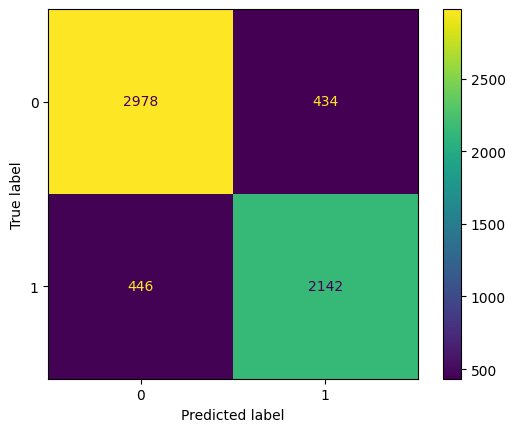

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [18]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(15))

            feature  importance
16       lat_p95_ms    0.268405
27    regime_medium    0.197659
24           reward    0.161838
3           PRBmean    0.087437
25  regime_impaired    0.048337
26     regime_light    0.046358
4            PRBp95    0.021783
11               UE    0.020014
13   DLthrmean_Mbps    0.014664
5           CQImean    0.011592
15       lat_p50_ms    0.009893
14   ULthrmean_Mbps    0.008725
7           SINR_dB    0.008429
6            CQIp05    0.007976
9           BLER_UL    0.007552


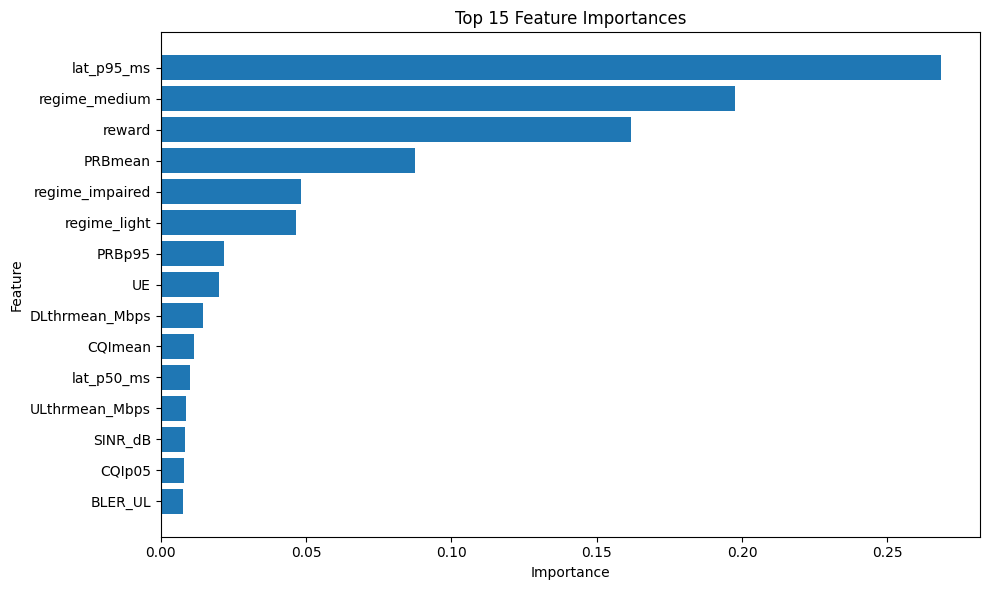

In [19]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [20]:
joblib.dump(model, "network_issue_model.pkl")
joblib.dump(X.columns.tolist(), "network_issue_columns.pkl")

print("Model saved successfully.")

Model saved successfully.


In [21]:
import os

drive_folder = "/content/drive/MyDrive/CoCare"
os.makedirs(drive_folder, exist_ok=True)

In [22]:
joblib.dump(model, f"{drive_folder}/network_issue_model.pkl")
joblib.dump(X.columns.tolist(), f"{drive_folder}/network_issue_columns.pkl")

['/content/drive/MyDrive/CoCare/network_issue_columns.pkl']

In [23]:
saved_model = joblib.load("network_issue_model.pkl")
saved_columns = joblib.load("network_issue_columns.pkl")

def predict_network_issue(data_dict):
    df_new = pd.DataFrame([data_dict])

    # حذف الأعمدة التي لا نستخدمها إذا وُجدت
    for col in ["sla_ok_next", "sla_ok_current", "client_id"]:
        if col in df_new.columns:
            df_new = df_new.drop(columns=[col])

    # one-hot encoding لـ regime
    if "regime" in df_new.columns:
        df_new = pd.get_dummies(df_new, columns=["regime"], drop_first=True)

    # إضافة الأعمدة الناقصة
    for col in saved_columns:
        if col not in df_new.columns:
            df_new[col] = 0

    # ترتيب الأعمدة
    df_new = df_new[saved_columns]

    prob = saved_model.predict_proba(df_new)[:, 1][0]
    pred = int(prob >= 0.5)

    return {
        "prediction": pred,
        "probability": prob
    }

In [24]:
sample = {
    "window_idx": 10,
    "timestamp_s": 900,
    "delta_s": 90,
    "PRBmean": 85.0,
    "PRBp95": 92.0,
    "CQImean": 8.5,
    "CQIp05": 6.8,
    "SINR_dB": 12.0,
    "BLER_DL": 0.06,
    "BLER_UL": 0.05,
    "HARQ_retx": 4,
    "UE": 24,
    "HO": 3,
    "DLthrmean_Mbps": 45.0,
    "ULthrmean_Mbps": 8.0,
    "lat_p50_ms": 40.0,
    "lat_p95_ms": 85.0,
    "slice_imbalance": 0.35,
    "slice_entropy": 1.4,
    "p_eMBB": 0.50,
    "p_URLLC": 0.20,
    "p_mMTC": 0.10,
    "p_XR": 0.15,
    "p_BE": 0.05,
    "reward": 0.70,
    "regime": "heavy"
}
255531
print(predict_network_issue(sample))

{'prediction': 1, 'probability': np.float32(0.9828572)}


In [25]:
!ls /content/drive/MyDrive/CoCare

 app.py     Intent_Ara		       'Notifications '    Sentiment_Eng
 COCARE     intent_Eng		        Prediction	   survery
 encoders   network_issue_columns.pkl   requirements.txt   utils
 engine     network_issue_model.pkl     Sentiment_Ara


In [38]:
from google.colab import files
uploaded = files.upload()

Saving network_prediction_production_level_test_full.csv to network_prediction_production_level_test_full (1).csv


Shape: (30000, 29)
Train: (24000, 28)
Test : (6000, 28)

===== MODEL PERFORMANCE =====
Train Accuracy: 0.8905
Test  Accuracy: 0.8533
Train AUC: 0.9636
Test  AUC: 0.9348
F1 Score: 0.8296

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      3412
           1       0.83      0.83      0.83      2588

    accuracy                           0.85      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.85      0.85      0.85      6000



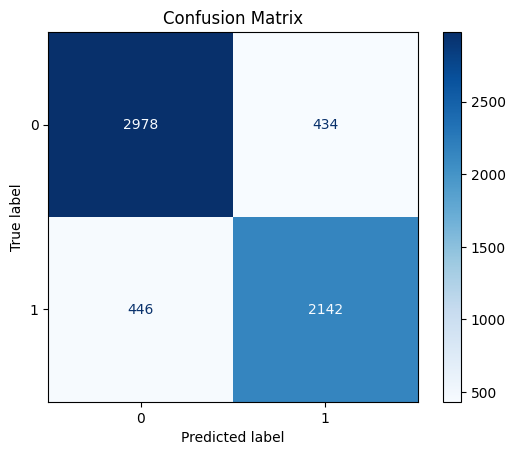


Top Features:
            feature  importance
16       lat_p95_ms    0.268405
27    regime_medium    0.197659
24           reward    0.161838
3           PRBmean    0.087437
25  regime_impaired    0.048337
26     regime_light    0.046358
4            PRBp95    0.021783
11               UE    0.020014
13   DLthrmean_Mbps    0.014664
5           CQImean    0.011592

Model saved ✔

Sample prediction:
{'prediction': 0, 'probability': np.float32(0.1741782)}

===== EXTERNAL TEST =====
Accuracy: 0.9353
F1: 0.9559

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       419
           1       0.94      0.97      0.96      1081

    accuracy                           0.94      1500
   macro avg       0.93      0.91      0.92      1500
weighted avg       0.93      0.94      0.93      1500



In [40]:
# =========================
# 1) Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


# =========================
# 2) Load Data
# =========================
df = pd.read_csv("6g_fl_telemetry_200_clients.csv")

print("Shape:", df.shape)

# =========================
# 3) Target Engineering
# =========================
df["network_issue_next"] = (df["sla_ok_next"] == 0).astype(int)

# =========================
# 4) Feature Engineering
# =========================
df_model = df.copy()

df_model = df_model.drop(columns=["sla_ok_next", "sla_ok_current", "client_id"])

df_model = pd.get_dummies(df_model, columns=["regime"], drop_first=True)

# =========================
# 5) Split
# =========================
X = df_model.drop(columns=["network_issue_next"])
y = df_model["network_issue_next"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# =========================
# 6) Model
# =========================
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================
# 7) Evaluation
# =========================
y_train_pred = model.predict(X_train)
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, y_test_prob)

f1 = f1_score(y_test, y_test_pred)

print("\n===== MODEL PERFORMANCE =====")
print("Train Accuracy:", round(train_acc, 4))
print("Test  Accuracy:", round(test_acc, 4))
print("Train AUC:", round(train_auc, 4))
print("Test  AUC:", round(test_auc, 4))
print("F1 Score:", round(f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================
# 8) Feature Importance
# =========================
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Features:")
print(importance.head(10))

# =========================
# 9) Save Model
# =========================
joblib.dump(model, "network_issue_model.pkl")
joblib.dump(X.columns.tolist(), "network_issue_columns.pkl")

print("\nModel saved ✔")


# =========================
# 10) Prediction Function
# =========================
saved_model = joblib.load("network_issue_model.pkl")
saved_columns = joblib.load("network_issue_columns.pkl")

def predict_network_issue(data_dict):
    df_new = pd.DataFrame([data_dict])

    # drop unwanted
    for col in ["sla_ok_next", "sla_ok_current", "client_id"]:
        if col in df_new.columns:
            df_new = df_new.drop(columns=[col])

    # one-hot
    if "regime" in df_new.columns:
        df_new = pd.get_dummies(df_new, columns=["regime"], drop_first=True)

    # add missing columns
    for col in saved_columns:
        if col not in df_new.columns:
            df_new[col] = 0

    df_new = df_new[saved_columns]

    prob = saved_model.predict_proba(df_new)[:, 1][0]
    pred = int(prob >= 0.5)

    return {"prediction": pred, "probability": prob}


# =========================
# 11) Sample Test
# =========================
sample = X_test.iloc[0].to_dict()
print("\nSample prediction:")
print(predict_network_issue(sample))


# =========================
# 12) External Test (Your File)
# =========================
test_path = "network_prediction_production_level_test_full.csv"
df_ext = pd.read_csv(test_path)

# تحويل الأعمدة بدون تسريب
converted = pd.DataFrame(index=df_ext.index)

converted["window_idx"] = np.arange(len(df_ext))
converted["timestamp_s"] = converted["window_idx"] * 10
converted["delta_s"] = 10

converted["PRBmean"] = df_ext["connected_users"].clip(0, 100)
converted["PRBp95"] = (df_ext["connected_users"] * 1.2).clip(0, 100)

converted["CQImean"] = (df_ext["signal_strength"] / 100 * 15).clip(1, 15)
converted["CQIp05"] = (converted["CQImean"] * 0.6).clip(1, 15)

converted["SINR_dB"] = (df_ext["signal_strength"] / 100 * 35 - 5).clip(-5, 30)

converted["BLER_DL"] = (df_ext["packet_loss"] / 100).clip(0, 1)
converted["BLER_UL"] = (df_ext["packet_loss"] / 120).clip(0, 1)

converted["HARQ_retx"] = (df_ext["packet_loss"] * 5).clip(0, 100)
converted["UE"] = df_ext["connected_users"]
converted["HO"] = (df_ext["jitter"] / 2).clip(0, 100)

converted["DLthrmean_Mbps"] = df_ext["throughput"]
converted["ULthrmean_Mbps"] = (df_ext["throughput"] * 0.35).clip(0, 100)

converted["lat_p50_ms"] = df_ext["latency"]
converted["lat_p95_ms"] = (df_ext["latency"] + df_ext["jitter"])

converted["slice_imbalance"] = (df_ext["connected_users"] / 300).clip(0, 1)
converted["slice_entropy"] = (1 - converted["slice_imbalance"]).clip(0, 1)

converted["p_eMBB"] = 0.35
converted["p_URLLC"] = 0.15
converted["p_mMTC"] = 0.20
converted["p_XR"] = 0.10
converted["p_BE"] = 0.20

converted["reward"] = (
    1
    - (df_ext["latency"] / 500)
    - (df_ext["packet_loss"] / 20)
    + (df_ext["throughput"] / 100)
).clip(-1, 1)

# بدون leakage
converted["regime_impaired"] = (
    (df_ext["latency"] > 180) |
    (df_ext["packet_loss"] > 8)
).astype(int)

converted["regime_light"] = (df_ext["connected_users"] < 50).astype(int)
converted["regime_medium"] = (df_ext["connected_users"] >= 50).astype(int)

X_ext = converted.reindex(columns=saved_columns, fill_value=0)
y_ext = df_ext["network_issue"].astype(int)

y_ext_pred = saved_model.predict(X_ext)

print("\n===== EXTERNAL TEST =====")
print("Accuracy:", round(accuracy_score(y_ext, y_ext_pred), 4))
print("F1:", round(f1_score(y_ext, y_ext_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_ext, y_ext_pred))